# 1. Setup and Imports
Import standard data science and machine learning libraries. We will also suppress warnings for cleaner outputs.

In [1]:
import os
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_theme(style="whitegrid")

# 2. Data Loading
Load the `train.csv` and `test.csv` datasets. Ensure that the paths reflect where your data is stored.


In [2]:
# Assuming data is stored in the '../data' directory relative to notebooks
DATA_DIR = '/kaggle/input/competitions/playground-series-s6e6'
train_path = os.path.join(DATA_DIR, 'train.csv')
test_path = os.path.join(DATA_DIR, 'test.csv')

# Load the data
try:
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    print("Data loaded successfully.")
    
    display(train_df.head())
    print("-" * 50)
    train_df.info()
    print("-" * 50)
    display(train_df.describe())
except FileNotFoundError:
    print(f"Files not found. Please ensure train.csv and test.csv are located in {DATA_DIR}")
    train_df = pd.DataFrame()
    test_df = pd.DataFrame()


Data loaded successfully.


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB
--------------------------------------------------


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


# 3. Exploratory Data Analysis (EDA)
Check the distribution of the target variable to identify class imbalances, and plot correlation matrices for numerical features.


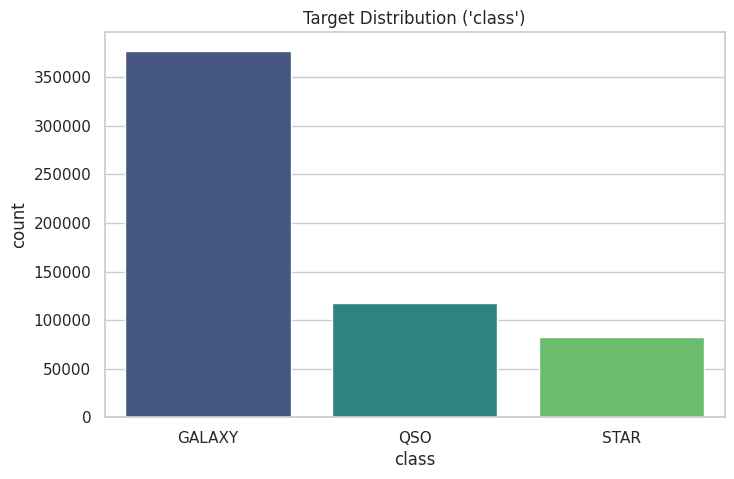

Class distribution percentages:
 class
GALAXY    65.381824
QSO       20.289878
STAR      14.328298
Name: proportion, dtype: float64


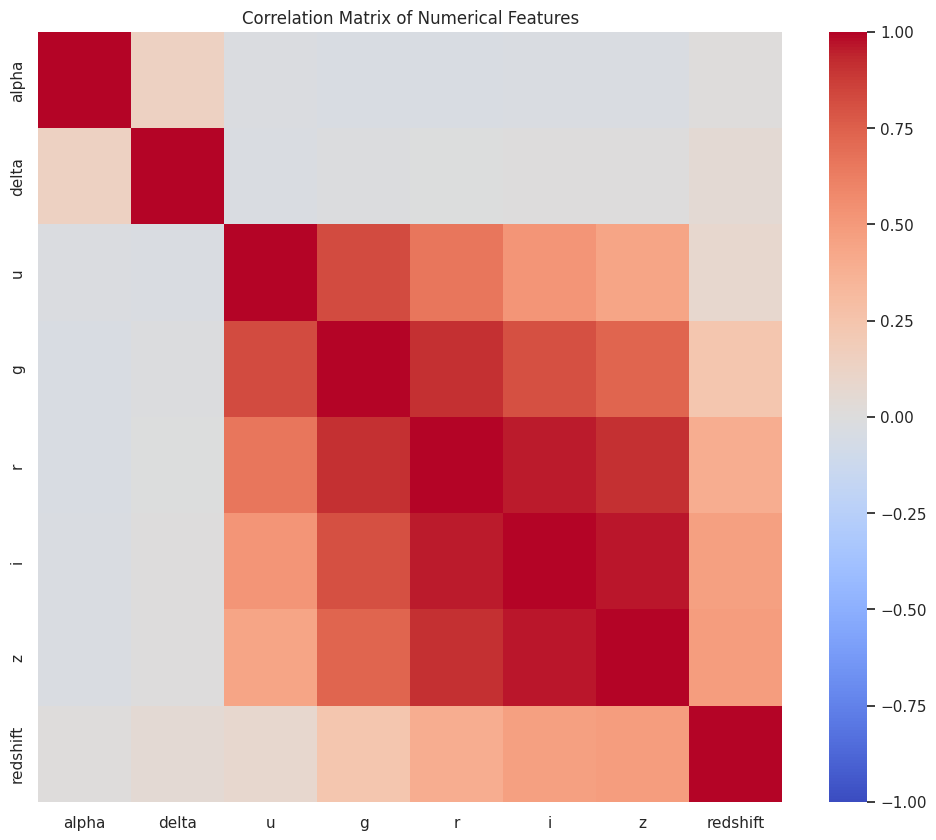

In [3]:
if not train_df.empty and 'class' in train_df.columns:
    # Plot Target Distribution
    plt.figure(figsize=(8, 5))
    sns.countplot(data=train_df, x='class', palette='viridis')
    plt.title("Target Distribution ('class')")
    plt.show()
    
    # Calculate percentages
    class_counts = train_df['class'].value_counts(normalize=True) * 100
    print("Class distribution percentages:\n", class_counts)
    
    # Select numerical features for correlation matrix
    num_features = train_df.select_dtypes(include=[np.number]).columns.tolist()
    if 'id' in num_features:
        num_features.remove('id')
        
    # Plot Correlation Matrix
    if len(num_features) > 0:
        plt.figure(figsize=(12, 10))
        corr = train_df[num_features].corr()
        sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
        plt.title("Correlation Matrix of Numerical Features")
        plt.show()


# 4. Data Preprocessing & Feature Engineering
Handle missing or infinite values, create domain-agnostic and astronomical tabular features, and label encode the target.


In [4]:
def preprocess_and_engineer_features(df, is_train=True, le=None):
    df = df.copy()
    
    # 1. Handle missing and infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(df.median(numeric_only=True), inplace=True) 
    
    # Identify numerical columns (excluding id and target)
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if 'id' in num_cols: num_cols.remove('id')
    if 'class' in num_cols: num_cols.remove('class')
    
    # Feature Engineering Step 1: Statistical Aggregations across rows
    if len(num_cols) > 0:
        df['row_mean'] = df[num_cols].mean(axis=1)
        df['row_std'] = df[num_cols].std(axis=1)
        df['row_skew'] = df[num_cols].skew(axis=1)
    
    # Feature Engineering Step 2: Mathematical Ratios
    # Creating a ratio between the first two features as an example
    if len(num_cols) >= 2:
        df['f1_f2_ratio'] = df[num_cols[0]] / (df[num_cols[1]] + 1e-8)
        
    # Feature Engineering Step 3: Log Transformations
    for col in num_cols[:5]: # applying to first 5 for demonstration
        df[f'{col}_log'] = np.log1p(np.abs(df[col]))
        
    # Feature Engineering Step 4 (Domain specific requested): Astronomical color indices
    # u, g, r, i, z are typical astronomical filters
    filter_cols = ['u', 'g', 'r', 'i', 'z']
    if all(col in df.columns for col in filter_cols):
        df['u-g'] = df['u'] - df['g']
        df['g-r'] = df['g'] - df['r']
        df['r-i'] = df['r'] - df['i']
        df['i-z'] = df['i'] - df['z']

    # Target Encoding
    target = None
    if is_train and 'class' in df.columns:
        if le is None:
            le = LabelEncoder()
            target = le.fit_transform(df['class'])
        else:
            target = le.transform(df['class'])
        df.drop(columns=['class'], inplace=True)
        
    return df, target, le

if not train_df.empty:
    X_train_full, y_train_full, label_encoder = preprocess_and_engineer_features(train_df, is_train=True)
    X_test_full, _, _ = preprocess_and_engineer_features(test_df, is_train=False, le=label_encoder)
    
    # Drop ID column for training
    features = [c for c in X_train_full.columns if c != 'id']
    X_train = X_train_full[features]
    X_test = X_test_full[features]
    
    print(f"Train shape: {X_train.shape}")
    print(f"Test shape: {X_test.shape}")


Train shape: (577347, 23)
Test shape: (247435, 23)


# 5. Model Training & Validation Setup
Set up a robust 5-fold Stratified K-Fold cross-validation strategy. We'll define a baseline LightGBM model optimized for multi-class classification.


In [6]:
N_FOLDS = 5

if not train_df.empty:
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    
    # Initialize arrays to store OOF predictions and test predictions
    oof_preds = np.zeros(len(X_train))
    test_preds = np.zeros((len(X_test), 3)) # 3 target classes
    
    # Store feature importances
    feature_importances = pd.DataFrame({'feature': features})
    
    # LightGBM parameters 
    lgb_params = {
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'multi_error',
        'boosting_type': 'gbdt',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'max_depth': -1,
        'feature_fraction': 0.8,
        'random_state': 42,
        'verbose': -1,
        'n_estimators': 1000
    }


# 6. Model Evaluation
Train the model across the folds, evaluate using the out-of-fold Balanced Accuracy score, and plot the feature importances.


=== Fold 1/5 ===
Fold 1 Balanced Accuracy: 0.95355

=== Fold 2/5 ===
Fold 2 Balanced Accuracy: 0.95502

=== Fold 3/5 ===
Fold 3 Balanced Accuracy: 0.95471

=== Fold 4/5 ===
Fold 4 Balanced Accuracy: 0.95600

=== Fold 5/5 ===
Fold 5 Balanced Accuracy: 0.95738

OOF Balanced Accuracy Score: 0.95533


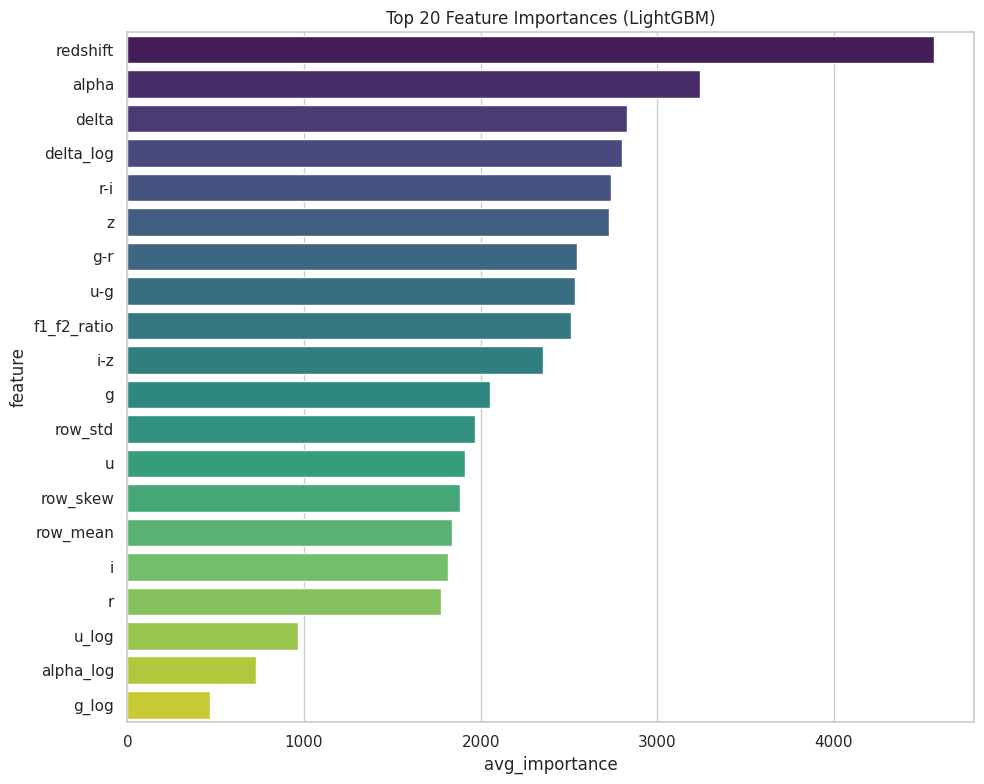

In [8]:
# 1. Identify your categorical columns
categorical_cols = ['spectral_type', 'galaxy_population']

# 2. Convert them to pandas 'category' dtype in both Train and Test sets
for col in categorical_cols:
    X_train[col] = X_train[col].astype('category')
    
    # Assuming you have an X_test DataFrame for your predictions later:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

# --- Your original code continues here ---
if not train_df.empty:
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train_full)):
        print(f"=== Fold {fold + 1}/{N_FOLDS} ===")
        
        X_tr, y_tr = X_train.iloc[train_idx], y_train_full[train_idx]
        X_va, y_va = X_train.iloc[val_idx], y_train_full[val_idx]
        
        # Initialize and train model
        model = lgb.LGBMClassifier(**lgb_params)
        
        # Fit with early stopping
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
        )
        
        # Predict on validation set
        val_preds_proba = model.predict_proba(X_va)
        val_preds_class = np.argmax(val_preds_proba, axis=1)
        
        # Calculate Balanced Accuracy
        score = balanced_accuracy_score(y_va, val_preds_class)
        fold_scores.append(score)
        print(f"Fold {fold + 1} Balanced Accuracy: {score:.5f}\n")
        
        # Store out-of-fold predictions
        oof_preds[val_idx] = val_preds_class
        
        # Accumulate test predictions
        test_preds += model.predict_proba(X_test) / N_FOLDS
        
        # Store feature importance
        feature_importances[f'fold_{fold}'] = model.feature_importances_
        
    cv_score = balanced_accuracy_score(y_train_full, oof_preds)
    print("=" * 50)
    print(f"OOF Balanced Accuracy Score: {cv_score:.5f}")
    
    # Plot feature importances
    feature_importances['avg_importance'] = feature_importances[[f'fold_{f}' for f in range(N_FOLDS)]].mean(axis=1)
    top_features = feature_importances.sort_values(by='avg_importance', ascending=False).head(20)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x='avg_importance', y='feature', palette='viridis')
    plt.title('Top 20 Feature Importances (LightGBM)')
    plt.tight_layout()
    plt.show()


# 7. Inference & Submission
Predict on the test set using averaged predictions from all folds, inverse-transform the predictions, and save `submission.csv`.


In [9]:
if not train_df.empty:
    # Final test predictions
    final_test_preds = np.argmax(test_preds, axis=1)
    
    # Inverse transform to original string labels ('GALAXY', 'STAR', 'QSO')
    final_labels = label_encoder.inverse_transform(final_test_preds)
    
    # Create submission dataframe
    submission = pd.DataFrame({
        'id': X_test_full['id'],
        'class': final_labels
    })
    
    # Save submission
    submission_path = 'submission.csv'
    submission.to_csv(submission_path, index=False)
    
    print(f"Submission saved to {submission_path}")
    display(submission.head())


Submission saved to submission.csv


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
